<a href="https://colab.research.google.com/github/blackdragonae/h0wsh2021/blob/main/HubbleConstant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[link text](https://)
**La constantante de Hubble con Galaxias HII**
---



Sincronizando el Drive de google

In [1]:
#import os
#from google.colab import drive
#drive.mount('/content/drive')

Instalando la librerias de python para hacer los calculos:

In [2]:
#!pip install zeus-mcmc
#!pip install getdist

## HOME Directory

In [1]:
import os
HOME = os.path.expanduser("~") + '/gdrive/DataHII/'

Importando las librerias necesarias para los calculos

In [2]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt
import os
from astropy.table import Table
from astropy.cosmology import FlatwCDM
from getdist import plots, MCSamples
import zeus
from zeus import ChainManager
import numpy as np
import scipy.optimize as op
from multiprocessing import Pool

Función Log Likelihood

In [3]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0 = theta

    Or = 4.153e-5 * h0**(-2)
    Om = 0.3
    w0 = -1.0

    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)
    #---------------------------------------------------------------------------
    ixG = np.where(z>10)
    ixH = np.where(z<10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2*W)
    llq = -0.5*xsq
    return (llq, xsq, R, Mum)

Definición de los priors

In [4]:
def lnprior(theta):
    alpha, beta, h0 = theta
    if (0.0 <= beta <= 10.0 and 20.0 <= alpha <= 40.0 and 0.5 <= h0 <= 1.0):
        return 0.0
    return -np.inf

Función de Log Posterior

In [5]:
def lnpost(theta, x, y, z, xerr, yerr, zerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr)[0]

Función de lectura de datos

In [9]:
def h2gdat(dpath):
    LSL = 1.83
    Tpath = dpath+'indat/Union2020v16.dat'
    data = Table.read(Tpath, format='ascii', comment='#')

    vix = data['col1']

    vx = data['col2']
    vy = data['col3']
    vz = data['col4']

    vxErr = data['col5']
    vyErr = data['col6']
    vzErr = data['col7']

    vsp = data['col8']

    rXY = np.corrcoef(vx, vy)
    vRxy = vx*0.0 + rXY[0,1]

    ix = np.where((vx - vxErr) <= LSL)

    return (vix[ix], vx[ix], vy[ix], vz[ix], vxErr[ix], vyErr[ix], vzErr[ix],
            vRxy[ix], vsp[ix])

Inicio del codigo principal, definición del directorio de datos

In [10]:
# Main Code

dpath = HOME + '/MCMC/ZEUS/h0wsh2023/dat/'
print('Data path:', dpath)

Data path: /home/holman/gdrive/DataHII//MCMC/ZEUS/h0wsh2023/dat/


Leyendo los datos

In [11]:
# Reading Data
vTg, vx, vy, vz, vxErr, vyErr, vzErr, vRxy, vsp = h2gdat(dpath)

Aproximación inicial para el resultado

In [12]:
# First guess
parameters = [r"\alpha", r"\beta", r"h"]
ialpha = 32.0
ibeta = 5.0
ih0 = 0.75

Cálculo de maximización de probablilidad

In [13]:
# Maximum Likelihood
nll = lambda *args: -lnlike(*args)[0]
result = op.minimize(nll, [ialpha, ibeta, ih0],
                args=(vx, vy, vz, vxErr, vyErr, vzErr)
            )
alpha_ml, beta_ml, h0_ml = result["x"]

print('max llq results:')
print('alpha = ', alpha_ml)
print('beta = ', beta_ml)
print('h = ', h0_ml)

max llq results:
alpha =  33.2169717140405
beta =  5.046006556006849
h =  0.7156989221484847


Cálculo de MCMC

In [14]:
# MCMC
nsteps = 1000
ndim, nwalkers = 3, 10
start = [[alpha_ml, beta_ml, h0_ml] + 1e-5*np.random.randn(ndim)
       for i in range(nwalkers)]

#with Pool() as pool:
sampler = zeus.EnsembleSampler(nwalkers, ndim, lnpost,
                                 args=(vx, vy, vz, vxErr, vyErr, vzErr)) #, pool=pool)
sampler.run_mcmc(start, nsteps)

sampler.summary

Initialising ensemble of 10 walkers...
Sampling progress : 100%|██████████| 1000/1000 [03:23<00:00,  4.91it/s]
Summary
-------
Number of Generations: 1000
Number of Parameters: 3
Number of Walkers: 10
Number of Tuning Generations: 38
Scale Factor: 1.047027
Mean Integrated Autocorrelation Time: 5.06
Effective Sample Size: 1977.01
Number of Log Probability Evaluations: 53020
Effective Samples per Log Probability Evaluation: 0.037288


Visulización de la cadena calculada

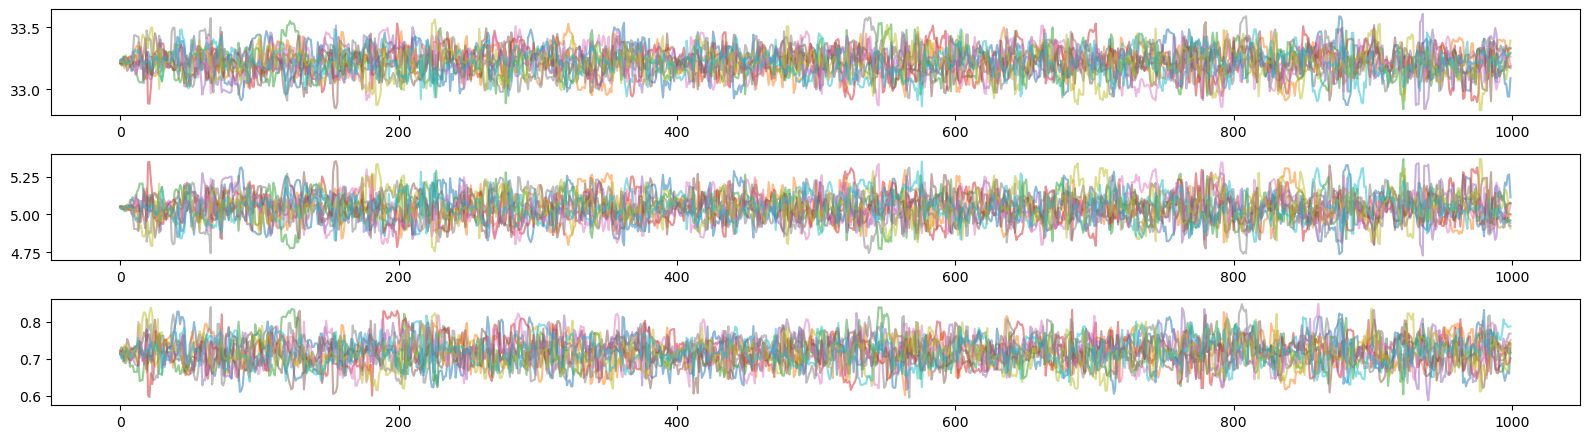

In [15]:
%matplotlib inline
path = dpath+'results/chain_test.pdf'
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n], alpha=0.5)
plt.tight_layout()
plt.savefig(path)
plt.show()

Eliminando burn-in y aplanando las cadenas

In [16]:
# flatten the chains, thin them by a factor of 1, and remove the burn-in (first 25% of the chain)
chain = sampler.get_chain(flat=True, discard=nsteps//4, thin=1)

Graficando resultados

Removed no burn in


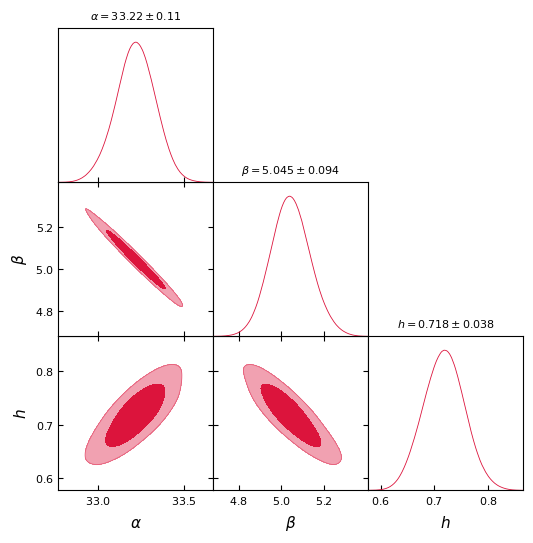

In [17]:
%matplotlib inline
tag = 'GDplot'
path = dpath+'results/GDplot.pdf'
GDsamples = MCSamples(samples=chain, names=parameters,
                          labels=parameters, name_tag=tag #,
                          # ranges={r"\Omega_m":[0.0, None]}
                          )

g = plots.getSubplotPlotter() #width_inch=4
g.settings.num_plot_contours = 2
g.triangle_plot(GDsamples, filled=True, title_limit=1,
            contour_colors=['crimson']
            # , param_limits={r"\alpha":[32.8, 33.7]
                        # , r"\beta":[4.7, 5.35]
                        # , r"h":[0.6, 0.85]
                        # , r"\Omega_m":[0.0, 0.52]
                        # , r"w_0":[-2.1, -0.2]
                        # }
            )
g.export(path)

Imprimiendo los resultados

In [18]:
t = GDsamples.getTable(limit=1).tableTex()
theta = GDsamples.getMeans()

# Print parameter values
print('parameter values:')
for name, col in zip(parameters, chain.transpose()):
  print('%15s : %.3f +- %.3f' % (name, col.mean(), col.std()))

print(t)

parameter values:
         \alpha : 33.218 +- 0.115
          \beta : 5.045 +- 0.094
              h : 0.718 +- 0.038
\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\alpha         $} & $33.22\pm 0.11             $\\

{\boldmath$\beta          $} & $5.045\pm 0.094            $\\

{\boldmath$h              $} & $0.718\pm 0.038            $\\
\hline
\end{tabular}


**Ejercicio 1:** Con el mismo procedimiento calcualar el conjunto de parametros ${\alpha, \beta, h, \Omega_m}$ utilizando un prior de $0.0 < \Omega_m < 1.0$


In [19]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0, Om = theta

    Or = 4.153e-5 * h0**(-2)
    w0 = -1.0

    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)
    #---------------------------------------------------------------------------
    ixG = np.where(z>10)
    ixH = np.where(z<10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2*W)
    llq = -0.5*xsq
    return (llq, xsq, R, Mum)

In [20]:
def lnprior(theta):
    alpha, beta, h0, Om = theta
    if (0.0 <= beta <= 10.0 and 20.0 <= alpha <= 40.0 and 0.5 <= h0 <= 1.0 and 0.0 <= Om <= 1.0):
        return 0.0
    return -np.inf

In [21]:
def lnpost(theta, x, y, z, xerr, yerr, zerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr)[0]

In [22]:
# First guess
parameters = [r"\alpha", r"\beta", r"h", r"\Omega_m"]
ialpha = 32.0
ibeta = 5.0
ih0 = 0.75
iOm = 0.3

In [23]:
# MCMC
nsteps = 1000
ndim, nwalkers = 4, 10
start = [[ialpha, ibeta, ih0, iOm] + 1e-5*np.random.randn(ndim)
       for i in range(nwalkers)]

with Pool() as pool:
  sampler = zeus.EnsembleSampler(nwalkers, ndim, lnpost, maxiter=20000,
                                 args=(vx, vy, vz, vxErr, vyErr, vzErr), pool=pool)
  sampler.run_mcmc(start, nsteps)

sampler.summary

Initialising ensemble of 10 walkers...
Sampling progress : 100%|██████████| 1000/1000 [04:22<00:00,  3.82it/s]
Summary
-------
Number of Generations: 1000
Number of Parameters: 4
Number of Walkers: 10
Number of Tuning Generations: 43
Scale Factor: 0.193411
Mean Integrated Autocorrelation Time: 7.72
Effective Sample Size: 1294.68
Number of Log Probability Evaluations: 94275
Effective Samples per Log Probability Evaluation: 0.013733


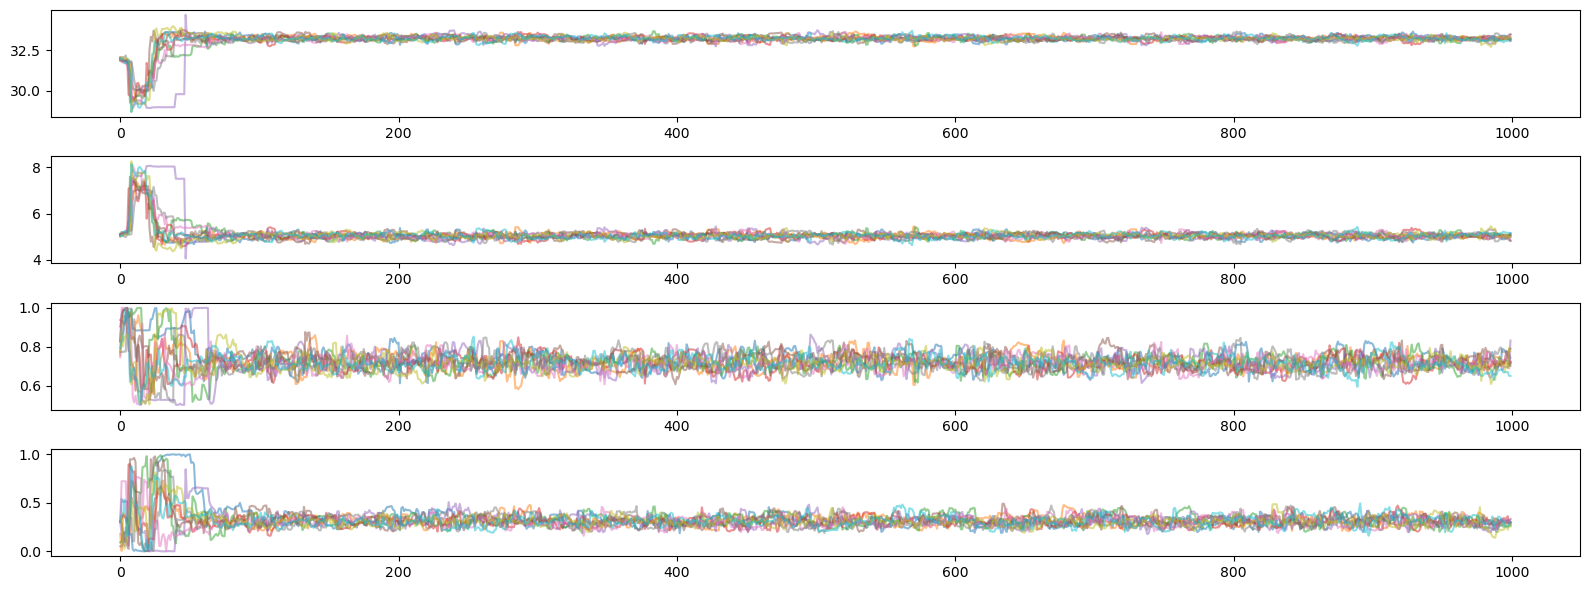

In [24]:
%matplotlib inline
path = dpath+'results/chain_test_Om.pdf'
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n], alpha=0.5)
plt.tight_layout()
plt.savefig(path)
plt.show()

In [25]:
# flatten the chains, thin them by a factor of 1, and remove the burn-in (first 25% of the chain)
chain = sampler.get_chain(flat=True, discard=nsteps//4, thin=1)

Removed no burn in


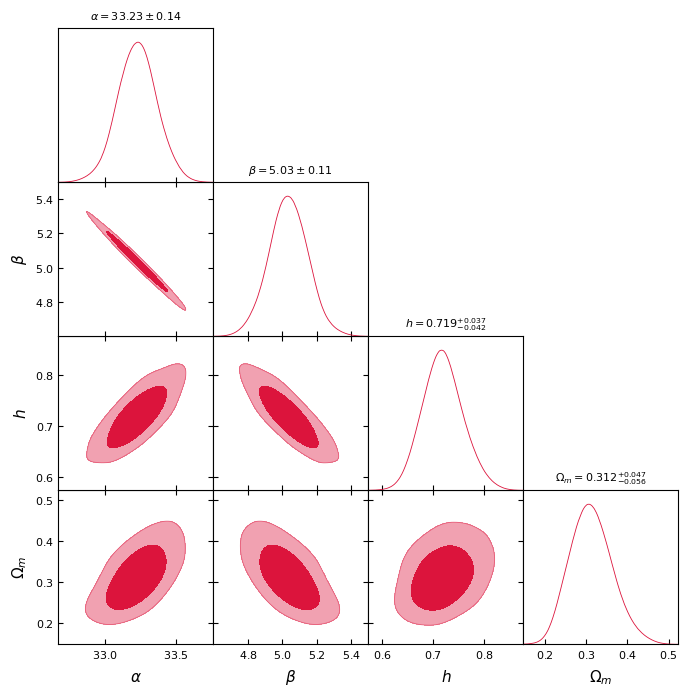

In [26]:
%matplotlib inline
tag = 'GDplot'
path = dpath+'results/GDplotOm.pdf'
GDsamples = MCSamples(samples=chain, names=parameters,
                          labels=parameters, name_tag=tag
                        , ranges={r"\Omega_m":[0.0, None]}
                          )

g = plots.getSubplotPlotter() #width_inch=4
g.settings.num_plot_contours = 2
g.triangle_plot(GDsamples, filled=True, title_limit=1,
            contour_colors=['crimson']
            # , param_limits={r"\alpha":[32.8, 33.7]
                        # , r"\beta":[4.7, 5.35]
                        # , r"h":[0.6, 0.85]
                        # , r"\Omega_m":[0.0, 0.52]
                        # , r"w_0":[-2.1, -0.2]
                        # }
            )
g.export(path)

**Ejercicio 2:** Con el mismo procedimiento calcualar el conjunto de parametros ${\alpha, \beta, h, \Omega_m, w_0}$ utilizando un prior de $0.0 < \Omega_m < 1.0$ y $-2.0 < w_0 < 1.0$

${w_0= -2.0}$  Tiene sentido fisico desde el punto de vista de la relatividad general?

In [27]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0, Om, wDE = theta

    Or = 4.153e-5 * h0**(-2)

    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=wDE)
    #---------------------------------------------------------------------------
    ixG = np.where(z>10)
    ixH = np.where(z<10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2*W)
    llq = -0.5*xsq
    return (llq, xsq, R, Mum)

In [28]:
def lnprior(theta):
    alpha, beta, h0, Om, wDE = theta
    if (0.0 <= beta <= 10.0 and 20.0 <= alpha <= 40.0 and 0.5 <= h0 <= 1.0 and 0.0 <= Om <= 1.0 and -2.0 <= wDE <= 1.0):
        return 0.0
    return -np.inf

In [29]:
def lnpost(theta, x, y, z, xerr, yerr, zerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr)[0]

In [30]:
# First guess
parameters = [r"\alpha", r"\beta", r"h", r"\Omega_m", r"w_0"]
ialpha = 32.0
ibeta = 5.0
ih0 = 0.75
iOm = 0.3
iwDE = -0.98

In [31]:
# MCMC
nsteps = 1000
ndim, nwalkers = 5, 10
start = [[ialpha, ibeta, ih0, iOm, iwDE] + 1e-5*np.random.randn(ndim)
       for i in range(nwalkers)]

with Pool() as pool:
  sampler = zeus.EnsembleSampler(nwalkers, ndim, lnpost, maxiter=20000,
                                 args=(vx, vy, vz, vxErr, vyErr, vzErr), pool=pool)
  sampler.run_mcmc(start, nsteps)

sampler.summary

Initialising ensemble of 10 walkers...
Sampling progress : 100%|██████████| 1000/1000 [02:57<00:00,  5.64it/s]
Summary
-------
Number of Generations: 1000
Number of Parameters: 5
Number of Walkers: 10
Number of Tuning Generations: 39
Scale Factor: 0.414303
Mean Integrated Autocorrelation Time: 18.69
Effective Sample Size: 535.05
Number of Log Probability Evaluations: 69807
Effective Samples per Log Probability Evaluation: 0.007665


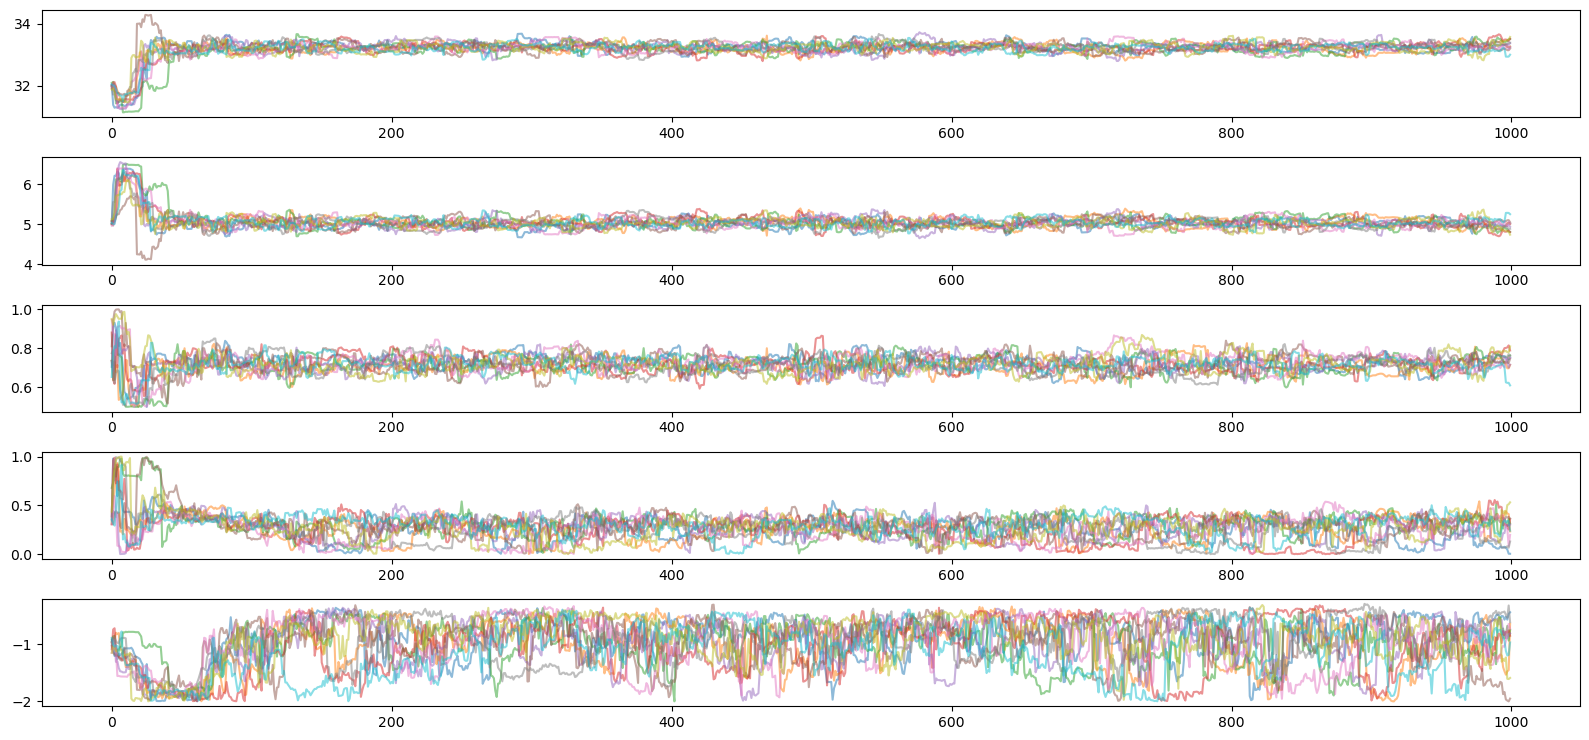

In [32]:
%matplotlib inline
path = dpath+'results/chain_test_wDE.pdf'
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n], alpha=0.5)
plt.tight_layout()
plt.savefig(path)
plt.show()

In [33]:
# flatten the chains, thin them by a factor of 1, and remove the burn-in (first 25% of the chain)
chain = sampler.get_chain(flat=True, discard=nsteps//4, thin=1)

Removed no burn in


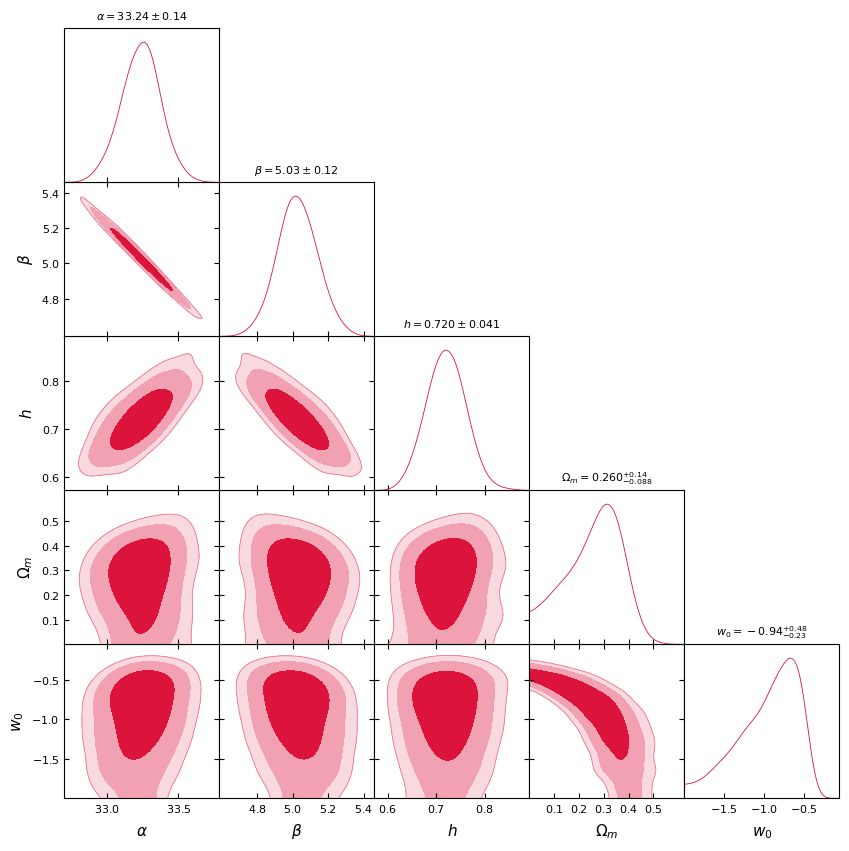

In [34]:
%matplotlib inline
tag = 'GDplot'
path = dpath+'results/GDplotwDE.pdf'
GDsamples = MCSamples(samples=chain, names=parameters,
                          labels=parameters, name_tag=tag
                        , ranges={r"w_0":[-2.0, None],r"\Omega_m":[0.0, None]}
                          )

g = plots.getSubplotPlotter() #width_inch=4
g.settings.num_plot_contours = 3
g.triangle_plot(GDsamples, filled=True, title_limit=1,
            contour_colors=['crimson']
            # , param_limits={r"\alpha":[32.8, 33.7]
                        # , r"\beta":[4.7, 5.35]
                        # , r"h":[0.6, 0.85]
                        # , r"\Omega_m":[0.0, 0.52]
                        # , r"w_0":[-2.1, -0.2]
                        # }
            )
g.export(path)

**Ejercicio 3:** Con el mismo procedimiento calcualar $h, \Omega_m, w_0$ fijando los valores de $\alpha = 33.22\pm 0.12$ y $\beta = 5.044\pm 0.094$.

In [35]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    h0, Om, w0 = theta

    Or = 4.153e-5 * h0**(-2)

    alpha = 33.22
    alphaErr = 0.12
    beta = 5.044
    betaErr = 0.094

    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)
    #---------------------------------------------------------------------------
    ixG = np.where(z>10)
    ixH = np.where(z<10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2 + x**2*(betaErr)**2 + alphaErr**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2*W)
    llq = -0.5*xsq
    return (llq, xsq, R, Mum)

In [36]:
def lnprior(theta):
    h0, Om, w0 = theta
    if (0.5 <= h0 <= 1.0 and 0.0 <= Om <= 1.0 and -2.0 <= w0 <= 1.0):
        return 0.0
    return -np.inf

In [37]:
def lnpost(theta, x, y, z, xerr, yerr, zerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr)[0]

In [38]:
# First guess
parameters = [r"h_0", r"\Omega_m", r"w_0"]
ih0 = 0.75
iOm = 0.3
iw0 = -1.0


In [39]:
# MCMC
nsteps = 1000
ndim, nwalkers = 3, 10
start = [[ih0, iOm, iw0] + 1e-5*np.random.randn(ndim)
       for i in range(nwalkers)]

with Pool() as pool:
  sampler = zeus.EnsembleSampler(nwalkers, ndim, lnpost, maxiter=20000,
                                 args=(vx, vy, vz, vxErr, vyErr, vzErr), pool=pool)
  sampler.run_mcmc(start, nsteps)

sampler.summary

Initialising ensemble of 10 walkers...
Sampling progress : 100%|██████████| 1000/1000 [02:35<00:00,  6.44it/s]
Summary
-------
Number of Generations: 1000
Number of Parameters: 3
Number of Walkers: 10
Number of Tuning Generations: 29
Scale Factor: 0.772175
Mean Integrated Autocorrelation Time: 8.08
Effective Sample Size: 1238.37
Number of Log Probability Evaluations: 68151
Effective Samples per Log Probability Evaluation: 0.018171


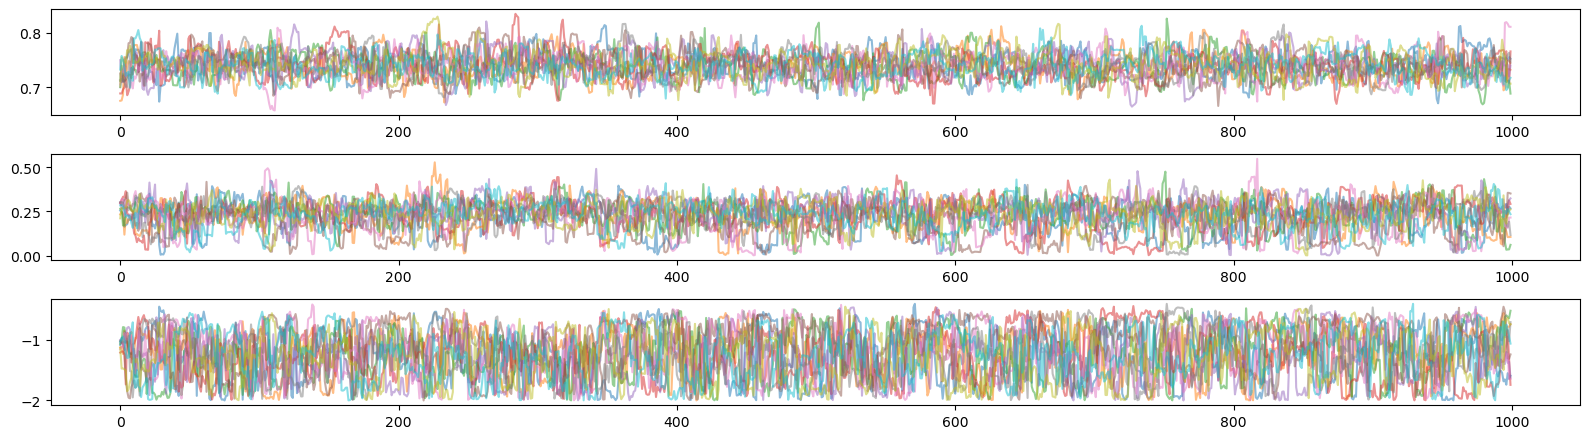

In [40]:
%matplotlib inline
path = dpath+'results/chain_test_w0.pdf'
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n], alpha=0.5)
plt.tight_layout()
plt.savefig(path)
plt.show()

In [41]:
# flatten the chains, thin them by a factor of 1, and remove the burn-in (first 25% of the chain)
chain = sampler.get_chain(flat=True, discard=nsteps//4, thin=1)

Removed no burn in


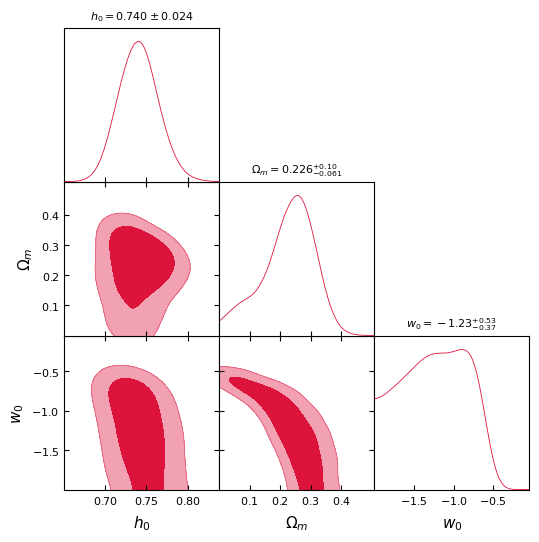

In [42]:
%matplotlib inline
tag = 'GDplot'
path = dpath+'results/GDplotw0.pdf'
GDsamples = MCSamples(samples=chain, names=parameters,
                          labels=parameters, name_tag=tag #,
                          , ranges={r"w_0":[-2.0, None],r"\Omega_m":[0.0, None]}
                          )

g = plots.getSubplotPlotter() #width_inch=4
g.settings.num_plot_contours = 2
g.triangle_plot(GDsamples, filled=True, title_limit=1,
            contour_colors=['crimson']
            # , param_limits={r"\alpha":[32.8, 33.7]
                        # , r"\beta":[4.7, 5.35]
                        # , r"h":[0.6, 0.85]
                        # , r"\Omega_m":[0.0, 0.52]
                        # , r"w_0":[-2.1, -0.2]
                        # }
            )
g.export(path)

**Ejercicio 4:** Con el mismo procedimiento calcualar $h, \Omega_m, w_0$ usando $\alpha = 33.22\pm 0.12$ y $\beta = 5.044\pm 0.094$ con priors gaussianos con $\mu$ y $\sigma$.

In [43]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0, Om, wDE = theta

    Or = 4.153e-5 * h0**(-2)

    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=wDE)
    #---------------------------------------------------------------------------
    ixG = np.where(z>10)
    ixH = np.where(z<10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2*W)
    llq = -0.5*xsq
    return (llq, xsq, R, Mum)

In [44]:
def lnprior(theta):
    alpha, beta, h0, Om, wDE = theta

    

    if not (0.5 <= h0 <= 1.0):
        return -np.inf
    if not (0.0 <= Om <= 1.0):
        return -np.inf
    if not (-2.0 <= wDE <= 1.0):
        return -np.inf

    lp = 0

    alpha_mu, alpha_sigma = 33.22 , 0.12
    beta_mu, beta_sigma = 5.044 , 0.094

    lp -= 0.5 * ((alpha - alpha_mu)/alpha_sigma)**2
    lp -= 0.5 * ((beta - beta_mu)/beta_sigma)**2

    return lp

In [45]:
def lnpost(theta, x, y, z, xerr, yerr, zerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr)[0]

In [46]:
# First guess
parameters = [r"\alpha", r"\beta", r"h", r"\Omega_m", r"w_0"]
ialpha = 33
ibeta = 5.0
ih0 = 0.72
iOm = 0.3
iwDE = -1.0

In [47]:
# MCMC
nsteps = 1000
ndim, nwalkers = 5, 10
start = [[ialpha, ibeta, ih0, iOm, iwDE] + 1e-5*np.random.randn(ndim)
       for i in range(nwalkers)]

with Pool() as pool:
  sampler = zeus.EnsembleSampler(nwalkers, ndim, lnpost, maxiter=20000,
                                 args=(vx, vy, vz, vxErr, vyErr, vzErr), pool=pool)
  sampler.run_mcmc(start, nsteps)

sampler.summary

Initialising ensemble of 10 walkers...
Sampling progress : 100%|██████████| 1000/1000 [02:35<00:00,  6.44it/s]
Summary
-------
Number of Generations: 1000
Number of Parameters: 5
Number of Walkers: 10
Number of Tuning Generations: 31
Scale Factor: 0.464855
Mean Integrated Autocorrelation Time: 22.16
Effective Sample Size: 451.33
Number of Log Probability Evaluations: 66152
Effective Samples per Log Probability Evaluation: 0.006823


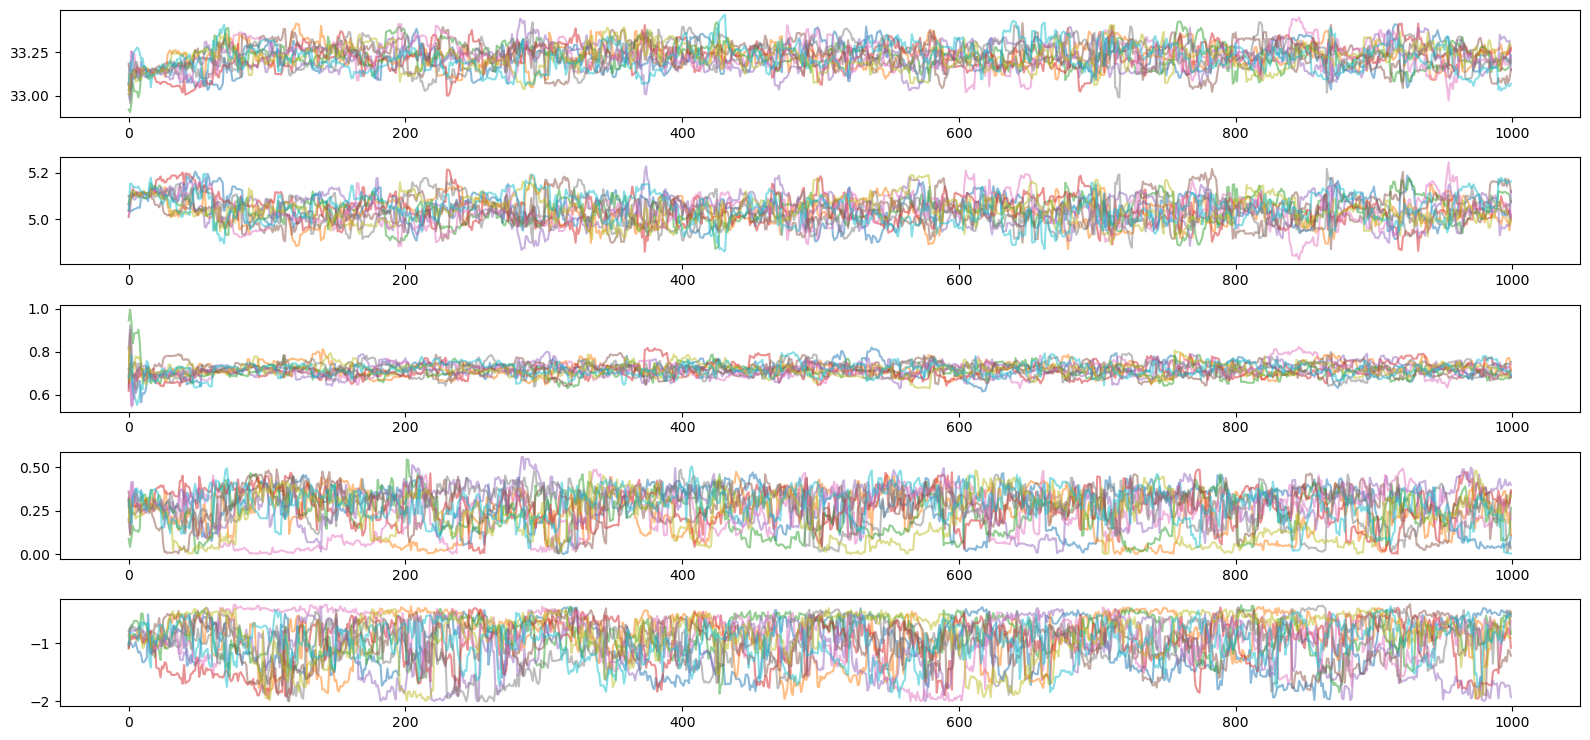

In [48]:
%matplotlib inline
path = dpath+'results/chain_test_wDE.pdf'
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n], alpha=0.5)
plt.tight_layout()
plt.savefig(path)
plt.show()

In [49]:
# flatten the chains, thin them by a factor of 1, and remove the burn-in (first 25% of the chain)
chain = sampler.get_chain(flat=True, discard=nsteps//4, thin=1)

Removed no burn in


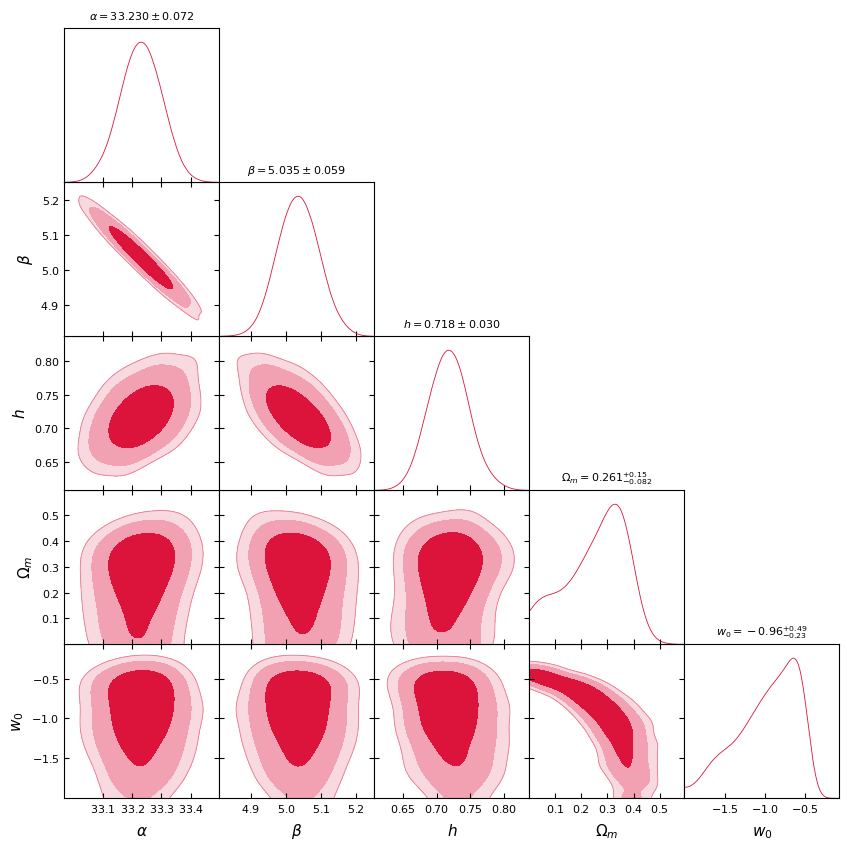

In [50]:
%matplotlib inline
tag = 'GDplot'
path = dpath+'results/GDplotwDE.pdf'
GDsamples = MCSamples(samples=chain, names=parameters,
                          labels=parameters, name_tag=tag
                        , ranges={r"w_0":[-2.0, None],r"\Omega_m":[0.0, None]}
                          )

g = plots.getSubplotPlotter() #width_inch=4
g.settings.num_plot_contours = 3
g.triangle_plot(GDsamples, filled=True, title_limit=1,
            contour_colors=['crimson']
            # , param_limits={r"\alpha":[32.8, 33.7]
                        # , r"\beta":[4.7, 5.35]
                        # , r"h":[0.6, 0.85]
                        # , r"\Omega_m":[0.0, 0.52]
                        # , r"w_0":[-2.1, -0.2]
                        # }
            )
g.export(path)

In [72]:
def h2gdat(dpath):
    LSL = 5000000
    Tpath = dpath+'indat/Union2020v16.dat'
    data = Table.read(Tpath, format='ascii', comment='#')

    vix = data['col1'] #id

    vx = data['col2'] #log sigma
    vy = data['col3'] #log flux
    vz = data['col4'] # z o mu

    vxErr = data['col5'] # error sigma
    vyErr = data['col6'] # error flux
    vzErr = data['col7'] # error z o mu

    vsp = data['col8'] # flag

    rXY = np.corrcoef(vx, vy)
    vRxy = vx*0.0 + rXY[0,1]

    ix = np.where((vx - vxErr) <= LSL)

    return (vix[ix], vx[ix], vy[ix], vz[ix], vxErr[ix], vyErr[ix], vzErr[ix],
            vRxy[ix], vsp[ix])

In [3]:
import numpy as np

data = np.loadtxt("/home/holman/gdrive/DataHII//MCMC/ZEUS/h0wsh2023/dat/indat/Union2020v16.dat")
idx        = data[:, 0].astype(int)
log_sigma  = data[:, 1]
log_fx     = data[:, 2]
z_or_mu    = data[:, 3]
err_logsig = data[:, 4]
err_logfx  = data[:, 5]
err_z_mu   = data[:, 6]
flag       = data[:, 7].astype(int)

In [12]:
mask_mu = idx <= 36      # o (np.arange(len(idx)) < 36)
mask_z  = ~mask_mu
mask_hiiloc = (flag == 1)

In [11]:
print(max(z_or_mu[mask_z]))
print(min(z_or_mu[mask_z]))

2.576
0.0088


In [13]:
print(max(z_or_mu[mask_hiiloc]))
print(min(z_or_mu[mask_hiiloc]))

0.16417
0.0088


In [101]:
import numpy as np
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

pc_to_cm = 3.08567758e18
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

In [102]:
logL = np.zeros_like(log_fx)
err_logL = np.zeros_like(log_fx)

# GEHRs (primeros 36)
mu = z_or_mu[mask_mu]
logf_mu = log_fx[mask_mu]
err_logf_mu = err_logfx[mask_mu]
err_mu = err_z_mu[mask_mu]

# logL = logf + 0.4 * mu + 40.078
logL[mask_mu] = logf_mu + 0.4 * mu + 40.078

# errores
err_logL[mask_mu] = np.sqrt(err_logf_mu**2 + (0.4 * err_mu)**2)

In [103]:
z = z_or_mu[mask_z]
logf_z = log_fx[mask_z]
err_logf_z = err_logfx[mask_z]
err_z = err_z_mu[mask_z]

# distancia de luminosidad
dL = cosmo.luminosity_distance(z)            # Mpc
dL_cm = dL.to(u.cm).value

logL[mask_z] = logf_z + 2*np.log10(dL_cm) + np.log10(4*np.pi)

# Propagación de errores en z (numérica)
logL_z = logL[mask_z].copy()
logL_z_plus = np.zeros_like(logL_z)

for i in range(len(z)):
    zp = z[i] + err_z[i]
    if zp <= 0:
        zp = z[i]  # por seguridad
    dL_p = cosmo.luminosity_distance(zp).to(u.cm).value
    logL_z_plus[i] = logf_z[i] + 2*np.log10(dL_p) + np.log10(4*np.pi)

sigma_logL_z = np.abs(logL_z_plus - logL_z)

err_logL[mask_z] = np.sqrt(err_logf_z**2 + sigma_logL_z**2)


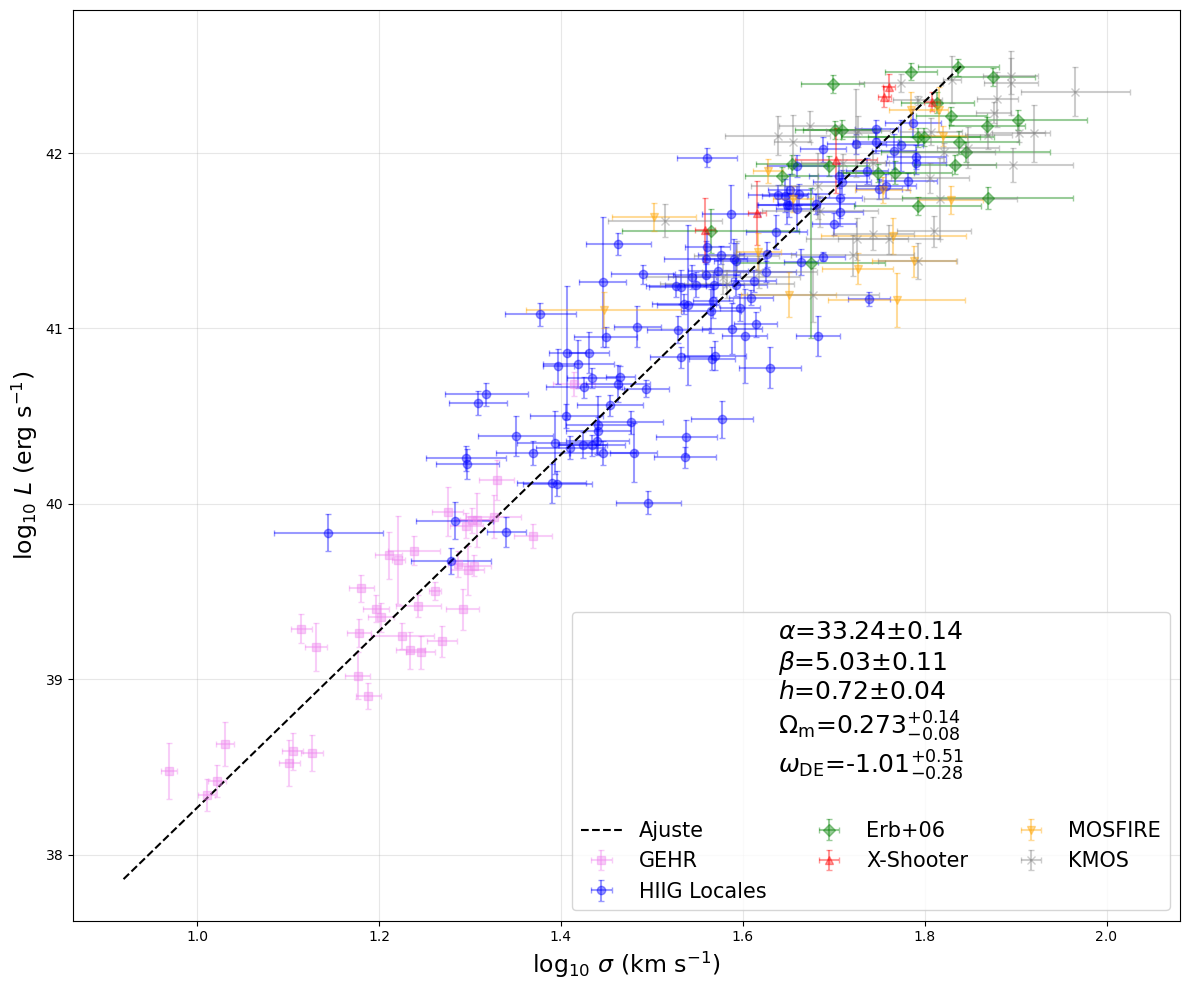

In [143]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

samples = {
    0: "GEHR",
    1: "HIIG Locales",
    2: "Erb+06",
    3: "X-Shooter",
    4: "MOSFIRE",
    5: "KMOS",
}

markers = {0: "s", 1: "o", 2: "D", 3: "^", 4: "v", 5: "x"}
colors = {0: "violet", 1: "blue", 2: "green", 3: "red", 4: "orange", 5: "gray"}

for s, label in samples.items():
    m = flag == s
    if not np.any(m):
        continue
    ax.errorbar(
        log_sigma[m],
        logL[m],
        color = colors[s],
        xerr=err_logsig[m],
        yerr=err_logL[m],
        fmt=markers[s],
        linestyle="none",
        label=label,
        alpha=0.4,
        capsize=2,
    )

ax.set_xlabel(r"$\log_{10}\, \sigma\ \mathrm{(km\ s^{-1})}$", fontsize = 17)
ax.set_ylabel(r"$\log_{10}\, L\ \mathrm{(erg\ s^{-1})}$", fontsize = 17)
ax.legend()
ax.grid(True, alpha=0.3)

#mask_fit = (flag == 0) | (flag == 1) | (flag == 2) | (flag == 3) | (flag == 4) | (flag == 5)
mask_fit = (flag == 0) | (flag == 1)


x = log_sigma[mask_fit]
y = logL[mask_fit]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

slope, intercept = 5.03 , 33.24 


# recta ajustada
x_line = np.linspace(x.min()-0.05, x.max()+0.05, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, label=r"Ajuste", color = 'k', linestyle = '--')
ax.legend(ncol= 3,
          title=r"$\alpha$=33.24$\pm$0.14" + "\n" + 
          r"$\beta$=5.03$\pm$0.11" + "\n" + 
          r"$h$=0.72$\pm$0.04" + "\n" + 
          r"$\Omega_\text{m}$=0.273$^{+0.14}_{-0.08}$" + "\n" + 
          r"$\omega_\text{DE}$=-1.01$^{+0.51}_{-0.28}$"+ "\n",
          title_fontsize=18,
          fontsize = 15)


plt.tight_layout()
plt.show()


In [106]:
from scipy import stats

# ejemplo: sólo GEHRs + HIIG locales (flag 0 y 1)
mask_fit = (flag == 0) | (flag == 1)

x = log_sigma[mask_fit]
y = logL[mask_fit]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# recta ajustada
x_line = np.linspace(x.min()-0.05, x.max()+0.05, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, label=f"Fit: a={slope:.2f}, b={intercept:.2f}")
ax.legend()
